## <span style="color:blue"> Lezione 11 </span>



In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Input

np.random.seed(0) 
tf.random.set_seed(0)


### <span style="color:DodgerBlue"> Esercizio 11.1 </span>



L'unità fondamentale di una rete neurale è il neurone. Esso prende in input gli $N$ valori $x_i$, in aggiunta ad $x_0=1$, e restituisce $A(\sum_{i=0}^N x_i w_i)$, dove $w_i$ sono detti _weights_ e $A$ è una funzione, detta _activation function_. $w_0$ è detto _bias_. 


Si considererà ora un semplicissimo esempio di neurone: quello che prende un solo input $x$ e non ha funzione di attivazione. Il suo output dipenderà da due parametri: $wx + b$. Ciò è sufficiente per descrivere la retta $f(x)=m x +q$. 

I dati per l'addestramento ($x_\mathrm{train},y_\mathrm{train}$) (in numero $N_\mathrm{train}$) e la validazione ($x_\mathrm{valid},y_\mathrm{valid}$) (in numero $N_\mathrm{valid}$) del modello vengono generati secondo la seguente procedura: 

1. Si estrae $x$ nell'intervallo $[-1,1]$ con probabilità uniforme.
2. Si calcola $f(x)$.
3. Si estrae $y$ da una gaussiana centrata in $f(x)$ e con deviazione standard $\sigma$ .


In [42]:
w = 2 # slope
b = 1 # intersect

In [43]:
def generate_data(N_train,sigma): 

    # generate training inputs

    x_train = np.random.uniform(-1, 1,N_train)
    x_valid = np.random.uniform(-1, 1, int(N_train/6))
    x_valid.sort()

    y_train = np.random.normal(w * x_train + b, sigma) # actual measures from which we want to guess regression parameters
    y_valid = np.random.normal(w * x_valid + b, sigma)
        
    return x_train,y_train,x_valid,y_valid

Una rete neurale viene addestrata, nell'ambito del _supervised learning_,  utilizzando un ottimizzatore per minimizzare una funzione costo (_loss_) $E(\vec{w})$ rispetto ai parametri della rete, $\vec{w}$. 
Per un problema di regressione, come quello in esame, la funzione costo più utilizzata è l'errore quadratico medio: 
$$
E(\vec{w})= \frac{1}{N}\sum_{j=1}^{N} ||f(\vec{x}_j,\vec{w})-\vec{y}_j||^2
$$

dove $(\vec{x}_j,\vec{y}_j)$ sono le coppie di dati del dataset di training (in addestramento), o validazione (in validazione) e $f(\vec{x}_j,\vec{w})$ è la predizione del modello per $\vec{x}_j$. 

La cella sottostante implementa la funzione per creare e compilare la rete neurale. Si è scelto come ottimizzatore SGD, _Stochastic Gradient Descent_.

In [44]:
def create_model():
    model = keras.Sequential()
    model.add(Dense(1, input_shape=(1,)))

    # compile the model choosing optimizer, loss and metrics objects
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    return model

Si vuole andare a valutare il comportamento della rete al variare di tre parametri: 
1. $N_\mathrm{train}$. $N_\mathrm{valid}$ sarà preso pari ad un decimo di $N_\mathrm{train}$.
2. $\sigma$
3. $N_\mathrm{epoch}$: numero di epoche di training (ogni epoca corrisponde all'avere utilizzato una volta tutti i dati)

In [45]:
N_train_list=[100,500,1000]
sigma_list=[0,0.5]
N_epoch=50
histories=[]

pams=[(N_train,sigma) for N_train in N_train_list for sigma in sigma_list]
models=[create_model() for i in range(len(pams))] # per non sovrascrivere il modello ad ogni passaggio


for (model,(N_train,sigma)) in zip(models,pams):

        x_train,y_train,x_valid,y_valid=generate_data(N_train,sigma)#genera i dati



        histories.append( model.fit(x=x_train, y=y_train, 
        batch_size=32, epochs=N_epoch, 
        validation_data=(x_valid, y_valid),
        verbose=1
        ))#addestra il modello

Epoch 1/50


2026-07-03 18:37:54.650827: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - loss: 1.3071 - mse: 1.3071 - val_loss: 1.5342 - val_mse: 1.5342
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1393 - mse: 1.1393 - val_loss: 1.3401 - val_mse: 1.3401
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.9960 - mse: 0.9960 - val_loss: 1.1727 - val_mse: 1.1727
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.8734 - mse: 0.8734 - val_loss: 1.0284 - val_mse: 1.0284
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7685 - mse: 0.7685 - val_loss: 0.9037 - val_mse: 0.9037
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.6784 - mse: 0.6784 - val_loss: 0.7959 - val_mse: 0.7959
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.6011 - mse: 0.6011 - val_loss: 0.7025 - val_mse: 0.7025
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5345 - mse: 0.5345 - val_loss: 0.6216 - val_mse: 0.6216
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4771 - mse: 0.4771 - val_loss: 

2026-07-03 18:38:06.940260: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 5.3615 - mse: 5.3615 - val_loss: 5.8720 - val_mse: 5.8720
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4.9542 - mse: 4.9542 - val_loss: 5.3074 - val_mse: 5.3074
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.5909 - mse: 4.5909 - val_loss: 4.8074 - val_mse: 4.8074
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.2657 - mse: 4.2657 - val_loss: 4.3637 - val_mse: 4.3637
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.9734 - mse: 3.9734 - val_loss: 3.9692 - val_mse: 3.9692
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.7098 - mse: 3.7098 - val_loss: 3.6178 - val_mse: 3.6178
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.4712 - mse: 3.4712 - val_loss: 3.3041 - val_mse: 3.3041
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.2544 - mse: 3.2544 - val_loss: 3.0236 - val_mse: 3.0236
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.0568 - mse: 3.0568 - val_loss: 

...

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 1.3452 - mse: 1.3452 - val_loss: 0.9277 - val_mse: 0.9277
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9156 - mse: 0.9156 - val_loss: 0.6414 - val_mse: 0.6414
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6723 - mse: 0.6723 - val_loss: 0.4800 - val_mse: 0.4800
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5298 - mse: 0.5298 - val_loss: 0.3862 - val_mse: 0.3862
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4430 - mse: 0.4430 - val_loss: 0.3295 - val_mse: 0.3295
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3875 - mse: 0.3875 - val_loss: 0.2937 - val_mse: 0.2937
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3503 - mse: 0.3503 - val_loss: 0.2703 - val_mse: 0.2703
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3243 - mse: 0.3243 - val_loss: 0.2543 - val_mse: 0.2543
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3053 - mse: 0.

2026-07-03 18:38:45.379231: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.6628 - mse: 3.6628 - val_loss: 2.8959 - val_mse: 2.8959
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2430 - mse: 2.2430 - val_loss: 1.7847 - val_mse: 1.7847
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4290 - mse: 1.4290 - val_loss: 1.1340 - val_mse: 1.1340
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9264 - mse: 0.9264 - val_loss: 0.7316 - val_mse: 0.7316
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6050 - mse: 0.6050 - val_loss: 0.4756 - val_mse: 0.4756
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3963 - mse: 0.3963 - val_loss: 0.3105 - val_mse: 0.3105
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2599 - mse: 0.2599 - val_loss: 0.2031 - val_mse: 0.2031
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1705 - mse: 0.1705 - val_loss: 0.1330 - val_mse: 0.1330
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1119 - mse: 0.1119 - 

2026-07-03 18:39:01.343491: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.5269 - mse: 2.5269 - val_loss: 2.1067 - val_mse: 2.1067
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5863 - mse: 1.5863 - val_loss: 1.3882 - val_mse: 1.3882
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0825 - mse: 1.0825 - val_loss: 0.9810 - val_mse: 0.9810
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7836 - mse: 0.7836 - val_loss: 0.7332 - val_mse: 0.7332
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5965 - mse: 0.5965 - val_loss: 0.5765 - val_mse: 0.5765
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4762 - mse: 0.4762 - val_loss: 0.4753 - val_mse: 0.4753
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3980 - mse: 0.3980 - val_loss: 0.4094 - val_mse: 0.4094
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3468 - mse: 0.3468 - val_loss: 0.3661 - val_mse: 0.3661
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3133 - mse: 0.3133 - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


2026-07-03 18:39:18.085534: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


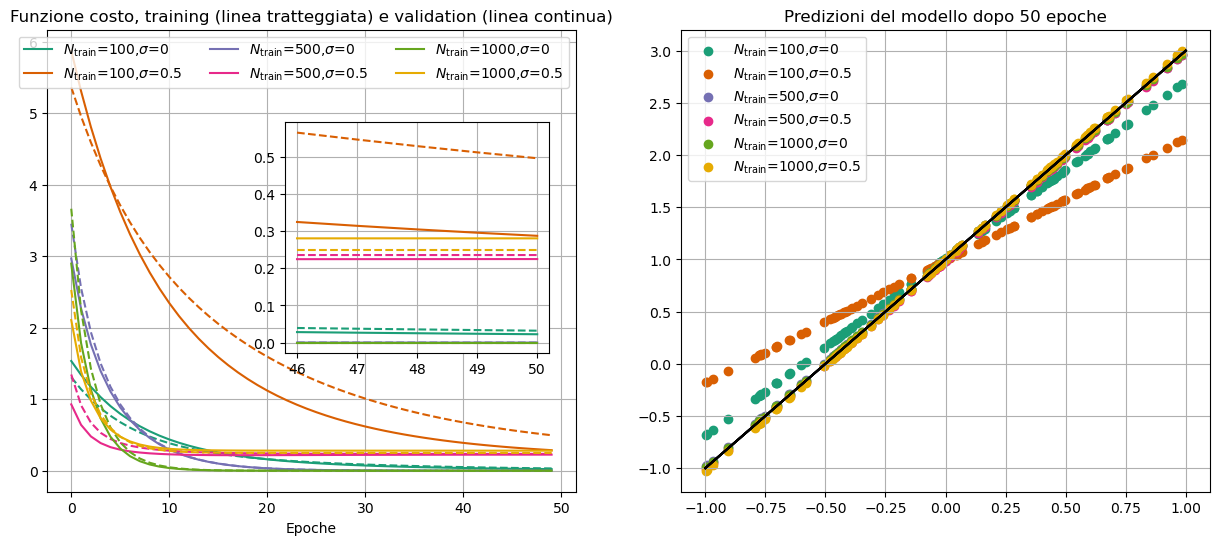

In [46]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

ax_ins = axs[0].inset_axes([0.45, 0.3, 0.5, 0.5]) #inserto

epochs=np.arange(1,N_epoch+1)

x=np.linspace(-1,1,100) #genera i dati per plot del target
x_pred=np.random.uniform(-1,1,100) 


colors = [plt.colormaps['Dark2'](i) for i in range(len(pams))]


for (color,model,history,(N_train,sigma)) in zip(colors,models,histories,pams):

    axs[0].plot(history.history['loss'],color=color,linestyle="--")
    axs[0].plot(history.history['val_loss'],color=color,label=fr"$N_{{\mathrm{{train}}}}$={N_train},$\sigma$={sigma}")
    axs[0].grid(True)
    axs[0].legend(ncol=3)
    axs[0].set_xlabel("Epoche")
    axs[0].set_title("Funzione costo, training (linea tratteggiata) e validation (linea continua)")
    ax_ins.plot(epochs[N_epoch-5:],history.history['loss'][N_epoch-5:],color=color,linestyle="--")
    ax_ins.plot(epochs[N_epoch-5:],history.history['val_loss'][N_epoch-5:],color=color,label=fr"$N_{{\mathrm{{train}}}}$={N_train},$\sigma$={sigma}")
    ax_ins.grid(True)
    axs[1].plot(x,w*x+b,color="black")
    y_pred=model.predict(x_pred)
    axs[1].scatter(x_pred,y_pred,color=color,label=fr"$N_{{\mathrm{{train}}}}$={N_train},$\sigma$={sigma}" )
    axs[1].grid(True)
    axs[1].legend()

    axs[1].set_title(r"Predizioni del modello dopo 50 epoche")





La funzione costo (grafico a sinistra) è decrescente in funzione del numero delle epoche  $N_{\mathrm{epochs}}$ e, in generale, tende ad assestarsi ad un valore fissato. Nel riquadro viene riportato uno zoom per evidenziare il diverso comportamento asintotico della funzione costo al variare di $\sigma$: per $\sigma \neq 0$ essa tende a stabilizzarsi ad un valore maggiore di $0$. 

Si nota che, per $N_{\mathrm{train}}=100$ con $\sigma=0$, la funzione costo dopo $50$ epoche è sensibilmente più alta delle altre due.
Nel grafico a destra si può notare come le predizioni associate siano sfalsate rispetto alla retta attesa. 

Complessivamente, si avranno predizioni migliori all'aumentare del numero dei dati di training $N_{\mathrm{train}}$, al diminuire del rumore $\sigma$, e all'aumentare del numero di epoche $N_{\mathrm{epochs}}$. Su quest'ultimo parametro bisogna fare ulteriori considerazioni: il trend decrescente della funzione costo di validazione può invertirsi. Ciò succede quando il modello va in _overfitting_, ossia adegua i parametri alle caratteristiche specifiche dei dati di training, perdendo capacità di generalizzazione. In questi casi, il numero di epoche corretto a cui fermare la fase di training è quello per cui la funzione di costo di validazione ha un minimo (_early stopping_). 

### <span style="color:DodgerBlue"> Esercizio 11.2 </span>



Per problemi più complessi, sono necessari numerosi neuroni, che vengono disposti in layer. Il primo layer, detto layer di input, si occupa dell'ingresso dei dati e deve avere dimensioni compatibili con la forma di essi. L'ultimo layer, detto layer di output, restituisce i risultati e ha dimensioni compatibili con la forma dell'output. In mezzo si può trovare un numero variabile di layer, detti _hidden layers_ . Il teorema di approssimazione universale afferma che data una rete neurale con un singolo layer nascosto è in grado di approssimare con arbitraria precisione una qualsiasi funzione continua multi-input e multi-output. La grandezza di questa rete, però, può crescere esponenzialmente rispetto alle dimensioni dell'input. Aumentando la profondità, _depth_ della rete neurale (ossia il numero di layer nascosti ), si riesce ad ottenere lo stesso risultato con un numero limitato di neuroni.

Nell'esercizio si effettuarà un fit del polinomio $f(x)=x^3-2x^2 -3x+4$ per $x \in [-1,1]$ (la cui implementazione in codice è riportata nella cella sottostante),  tramite l'utilizzo di un modello di rete neurale.  

In [47]:

def f(x):
    return 4-3*x-2*x**2+3*x**3

I parametri della rete neurale sono riportati nella cella sottostante: 

In [48]:
#parametri
batch_size=20
N_epoch=50
N_neurons=10 #numero di neuroni per layer
N_train=5000
N_val=500
activation_function='elu'

I dati per l'addestramento ($x_\mathrm{train},y_\mathrm{train}$) e la validazione ($x_\mathrm{valid},y_\mathrm{valid}$) del modello vengono generati come nell'esercizio precedente, con $\sigma=0.2$. 

In [49]:
#Generazione dati
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train).reshape(-1,1)
x_valid = np.random.uniform(-1, 1, N_val).reshape(-1,1)
x_valid.sort()
sigma = 0.2
y_train = np.random.normal(f(x_train), sigma)
y_valid = np.random.normal(f(x_valid), sigma)



Nelle celle sottostanti viene costruito e addestrato il modello. La rete neurale ha due layer nascosti. Si può inoltre notare che sia il layer di input che quello di output sono composti da un solo neurone, com'è appropriato per una rete volta ad approssimare una funzione da $\mathbb{R}$  a $\R$.

In [50]:

model = keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(N_neurons,activation=activation_function))
model.add(Dense(N_neurons,activation=activation_function))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
model.summary()


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:

history = model.fit(x=x_train, y=y_train, 
          batch_size=batch_size, epochs=N_epoch, 
          validation_data=(x_valid, y_valid),
          verbose=1
          )

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7260 - mse: 0.7260 - val_loss: 0.4750 - val_mse: 0.4750
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4202 - mse: 0.4202 - val_loss: 0.3798 - val_mse: 0.3798
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3323 - mse: 0.3323 - val_loss: 0.2932 - val_mse: 0.2932
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2531 - mse: 0.2531 - val_loss: 0.2164 - val_mse: 0.2164
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1858 - mse: 0.1858 - val_loss: 0.1591 - val_mse: 0.1591
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1413 - mse: 0.1413 - val_loss: 0.1249 - val_mse: 0.1249
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1154 - mse: 0.1154 - val_loss: 0.1038 - val_mse: 0.1038
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1001 - mse: 0.1001 - val_loss: 0.0909 - val_mse: 0.0909
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

Nella cella sottostante, si valuta la bontà del modello e si grafica la funzione costo (_loss_), confrontando  _training_ e  _validation_.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0461 - mse: 0.0461
Test loss: 0.04610450565814972


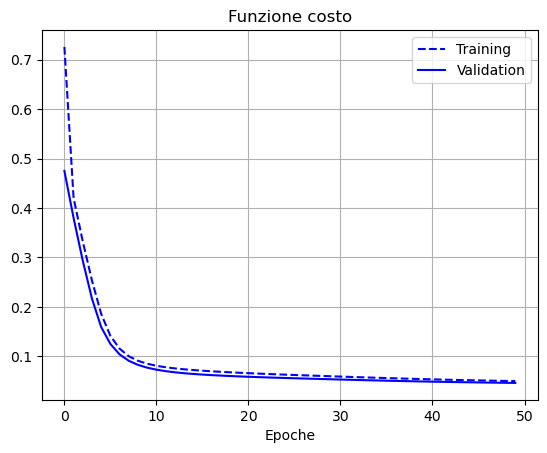

In [52]:

score = model.evaluate(x_valid, y_valid, batch_size=batch_size, verbose=1)
print('Test loss:', score[0])
plt.plot(history.history['loss'],"--",color="blue")
plt.plot(history.history['val_loss'],color="blue")
plt.grid() 
plt.title('Funzione costo')
plt.xlabel('Epoche')
plt.legend(['Training', 'Validation'], loc='best')
plt.show()



Nella cella sottostante, invece, si vuole andare a valutare la capacità predittiva del modello per $400$ valori di $x$, distribuite a spaziatura costante nell'intervallo $[-1.5,1.5]$.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


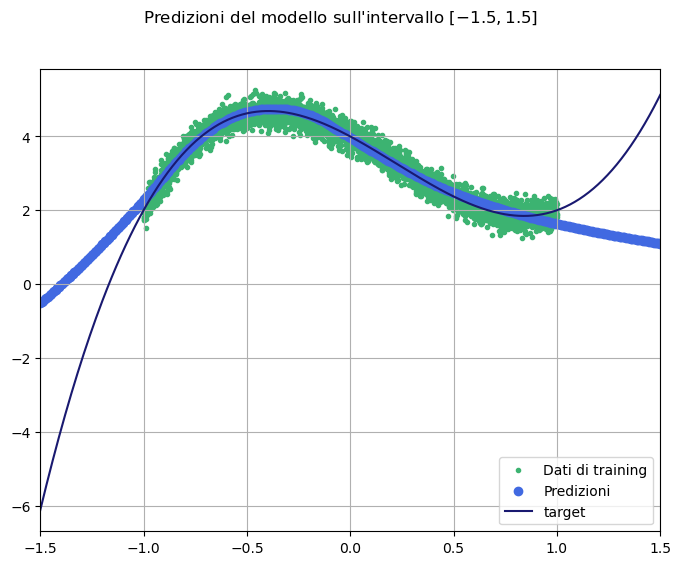

In [53]:

fig,ax=plt.subplots(1,1,figsize=[8,6])

x_test=np.linspace(-1.5,1.5,400).reshape(-1,1)



y_predicted = model.predict(x_test, batch_size=400)


ax.scatter(x_train,y_train,marker=".",label="Dati di training",color="mediumseagreen")

ax.scatter(x_test,y_predicted,color="royalblue",label="Predizioni")
ax.plot(x_test,f(x_test),color="midnightblue",label="target")

ax.set_xlim([-1.5,1.5])
ax.grid()

ax.legend()

fig.suptitle(r"Predizioni del modello sull'intervallo $[-1.5,1.5]$");


La figura mostra come il potere predittivo del modello si esaurisca al di fuori dai confini dell'intervallo dei dati usati per il training. 

### <span style="color:DodgerBlue"> Esercizio 11.3 </span>



Sempre tramite una rete neurale, si vuole ora effettuare un fit della funzione $g(x,y) =\sin(x^2+y^2) \coloneqq \mathbb{R}^2 \to \mathbb{R}$, per $x,y \in [-3/2,3/2]$. Il codice che implementa la funzione è riportato sotto. 

In [54]:
def g(x,y): 
    return np.sin(x**2+y**2)

Le celle sottostanti implementano i passaggi già discussi nell'esercizio precedente. 

In [55]:
#parametri
batch_size2=20
N_epoch2=70
N_neurons2=20
N_train2=10000
N_val2=2000
activation_function2='elu'

In [56]:
#Generazione dati
np.random.seed(0)
x_train2 = np.column_stack([ np.random.uniform(-3/2, 3/2, N_train2), np.random.uniform(-3/2, 3/2, N_train2)])
x_valid2 =np.column_stack([ np.random.uniform(-3/2, 3/2, N_val2), np.random.uniform(-3/2, 3/2, N_val2)])

sigma2 = 0.2
y_train2 = np.random.normal(g(x_train2[:,0],x_train2[:,1]), sigma2) 
y_valid2 = np.random.normal(g(x_valid2[:,0],x_valid2[:,1]), sigma2) 


I layer nascosti ora sono $5$, per adeguarsi alla maggiore complessità della funzione. Poichè la funzione è da $\R^2$ a $\R$, il layer di input ha dimensione due, mentre quello di output rimane formato da un solo neurone. 

In [57]:

model2 = keras.Sequential()
model2.add(Input(shape=(2,)))
model2.add(Dense(5*N_neurons2,activation=activation_function2))
model2.add(Dense(4*N_neurons2,activation=activation_function2))
model2.add(Dense(3*N_neurons2,activation=activation_function2))
model2.add(Dense(2*N_neurons2,activation=activation_function2))
model2.add(Dense(N_neurons2,activation=activation_function2))
model2.add(Dense(1))

model2.compile(optimizer='sgd', loss='mse', metrics=['mse'])
model2.summary()


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 60)             │         4,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 40)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,521 (64.54 KB)

 Trainable params: 16,521 (64.54 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:

history2 = model2.fit(x=x_train2, y=y_train2, 
          batch_size=batch_size2, epochs=N_epoch2, 
          validation_data=(x_valid2, y_valid2),verbose=1)

Epoch 1/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2008 - mse: 0.2008 - val_loss: 0.1976 - val_mse: 0.1976
Epoch 2/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1942 - mse: 0.1942 - val_loss: 0.1946 - val_mse: 0.1946
Epoch 3/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1910 - mse: 0.1910 - val_loss: 0.1917 - val_mse: 0.1917
Epoch 4/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1876 - mse: 0.1876 - val_loss: 0.1880 - val_mse: 0.1880
Epoch 5/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1829 - mse: 0.1829 - val_loss: 0.1821 - val_mse: 0.1821
Epoch 6/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1753 - mse: 0.1753 - val_loss: 0.1727 - val_mse: 0.1727
Epoch 7/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1638 - mse: 0.1638 - val_loss: 0.1595 - val_mse: 0.1595
Epoch 8/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1492 - mse: 0.1492 - val_loss: 0.1443 - val_mse: 0.1443
Epoch 9/70
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0428 - mse: 0.0428
Test loss: 0.04276863858103752


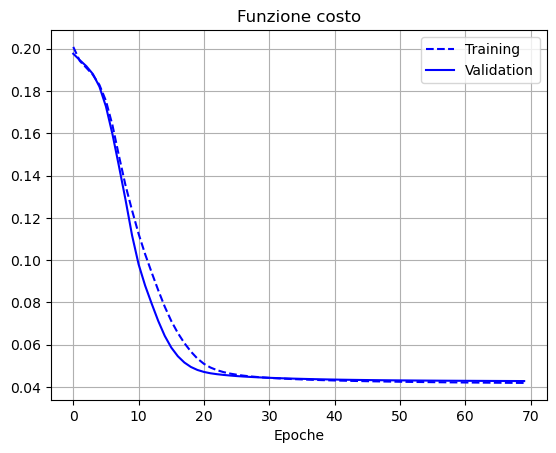

In [59]:

score2 = model2.evaluate(x_valid2, y_valid2, batch_size=batch_size2, verbose=1)
print('Test loss:', score2[0])
plt.plot(history2.history['loss'],"--",color="blue",label="Training")
plt.plot(history2.history['val_loss'],color="blue",label="Validation")
plt.grid()
plt.title('Funzione costo')
plt.xlabel('Epoche')
plt.legend()
plt.show()



22/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

2026-07-03 18:42:47.102517: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


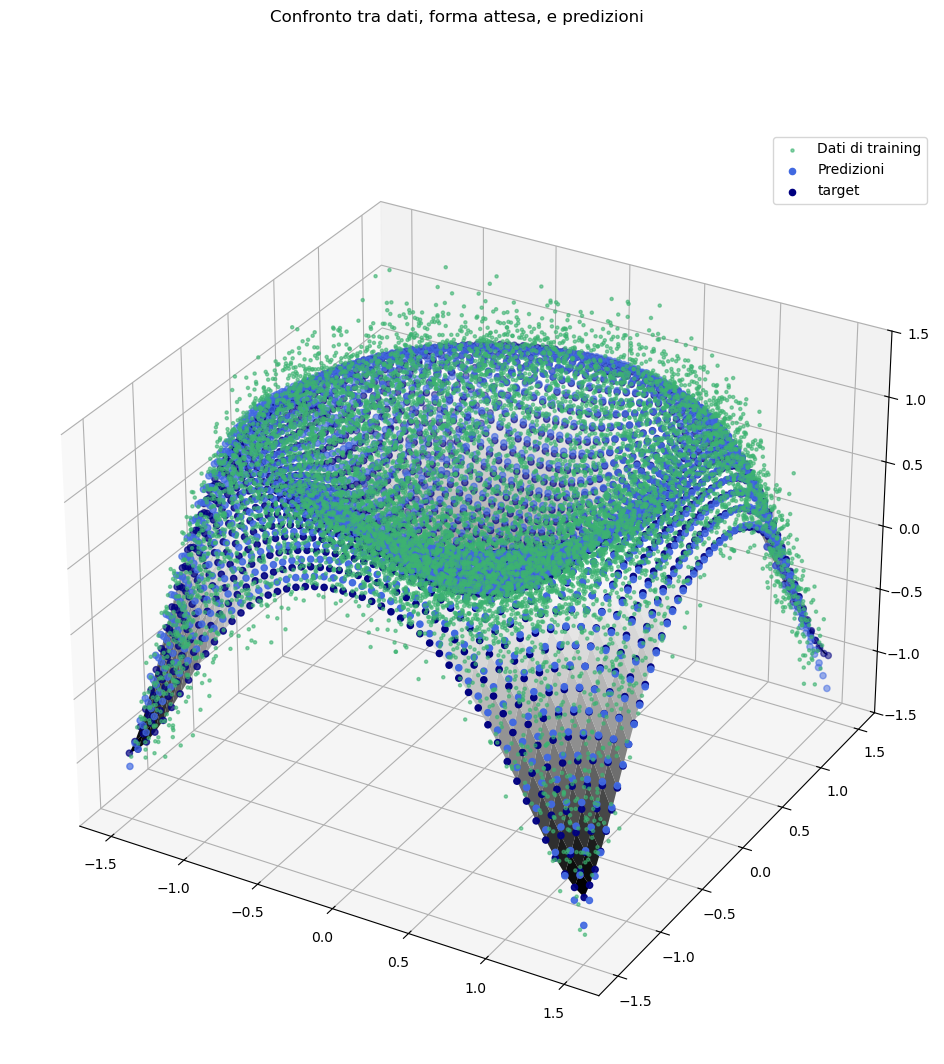

In [60]:

fig = plt.figure(figsize=[12,12])

x=np.linspace(-3/2,3/2,50)
y=np.linspace(-3/2,3/2,50)

xx,yy=np.meshgrid(x,y)
x_test_grid=np.column_stack([xx.ravel(),yy.ravel()])

y_predicted2=model2.predict(x_test_grid)


ax1 = fig.add_subplot(111, projection='3d')  

ax1.plot_surface(xx, yy, g(xx,yy), cmap='Greys_r')
ax1.scatter(x_train2[:,0],x_train2[:,1],y_train2,color="mediumseagreen",marker=".",label="Dati di training",alpha=0.6)
ax1.scatter(x_test_grid[:,0],x_test_grid[:,1],y_predicted2[:,0],color="royalblue",label="Predizioni");
ax1.scatter(x_test_grid[:,0],x_test_grid[:,1],g(x_test_grid[:,0],x_test_grid[:,1]),color="navy",label="target")


ax1.legend()
ax1.set_zlim3d([-1.5,1.5])


fig.suptitle("Confronto tra dati, forma attesa, e predizioni");


La rete è in grado di fornire discrete previsioni anche su dati rumorosi e funzioni più complesse come $\sin(x^2+y^2)$. 